# Chapter 5 — Multi-Agent RL
*Reinforcement Learning: An Overview*, Murphy (arXiv:2412.05265v5) — §5

Games · Nash equilibria · Solution concepts · MARL algorithms

In [1]:
%pip install -q numpy matplotlib scipy
print('ready')

/Users/ppcc/Desktop/Reinforcement-Learning/.venv/bin/python3: No module named pip


Note: you may need to restart the kernel to use updated packages.
ready


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

## 5.1 Normal-Form Games

Two-player zero-sum: payoff matrix $A$ (row player perspective).
Row maximises $x^T A y$; col minimises it.

In [3]:
# Rock (0) Paper (1) Scissors (2)
RPS = np.array([[ 0,-1, 1],
                [ 1, 0,-1],
                [-1, 1, 0]], dtype=float)

# Prisoner's Dilemma: Cooperate=0, Defect=1
PD_row = np.array([[3, 0], [5, 1]], dtype=float)

print("RPS payoff matrix (row player):")
print(RPS)
print("\nPrisoner's Dilemma (row player):")
print(PD_row)
print("\n(C,C)=3, (C,D)=0, (D,C)=5, (D,D)=1")
print("Defect dominates Cooperate for each player — social dilemma.")


RPS payoff matrix (row player):
[[ 0. -1.  1.]
 [ 1.  0. -1.]
 [-1.  1.  0.]]

Prisoner's Dilemma (row player):
[[3. 0.]
 [5. 1.]]

(C,C)=3, (C,D)=0, (D,C)=5, (D,D)=1
Defect dominates Cooperate for each player — social dilemma.


## 5.2 Nash Equilibrium via Linear Program

Minimax for zero-sum:
$$\max_x\min_y x^T Ay,\quad x,y\in\Delta$$

Dual LP gives both strategies in polynomial time.

In [4]:
def nash_zerosum(A):
    """Returns (row_strategy, col_strategy, game_value)."""
    m, n = A.shape
    # Row: max v  s.t. A^T x >= v*1, 1^T x=1, x>=0
    c     = np.append(np.zeros(m), -1.0)
    A_ub  = np.hstack([-A.T, np.ones((n,1))])
    A_eq  = np.array([np.append(np.ones(m), 0.0)])
    b_eq  = np.array([1.0])
    bounds = [(0,None)]*m + [(None,None)]
    res = linprog(c, A_ub=A_ub, b_ub=np.zeros(n),
                  A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")
    x = res.x[:m]; v = -res.fun

    # Col: min v  s.t. Ay <= v*1, 1^T y=1, y>=0
    c2    = np.append(np.zeros(n), 1.0)
    A_ub2 = np.hstack([A, -np.ones((m,1))])
    bounds2 = [(0,None)]*n + [(None,None)]
    res2 = linprog(c2, A_ub=A_ub2, b_ub=np.zeros(m),
                   A_eq=np.array([np.append(np.ones(n),0.0)]), b_eq=b_eq,
                   bounds=bounds2, method="highs")
    y = res2.x[:n]
    return x, y, v

x, y, v = nash_zerosum(RPS)
print(f"Row NE (R,P,S): {np.round(x,4)}")
print(f"Col NE (R,P,S): {np.round(y,4)}")
print(f"Game value:     {v:.4f}  (expected 0.0 — fair game)")


Row NE (R,P,S): [0.3333 0.3333 0.3333]
Col NE (R,P,S): [0.3333 0.3333 0.3333]
Game value:     -0.0000  (expected 0.0 — fair game)


## 5.3 Fictitious Play

Each player best-responds to the empirical frequency of opponent play.
Converges to Nash in two-player zero-sum games.

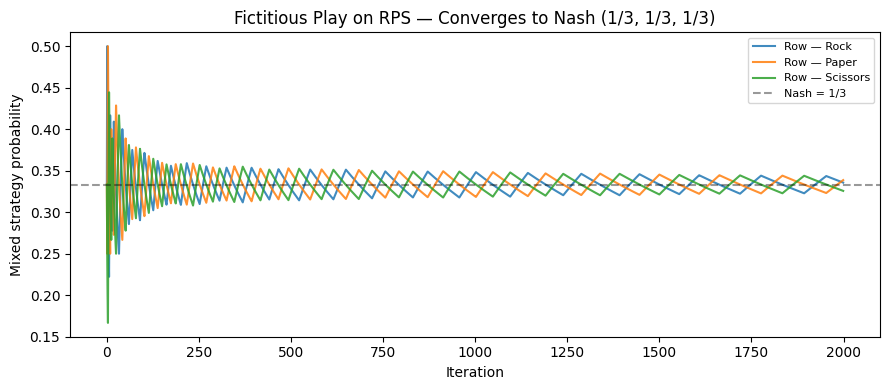

In [5]:
def fictitious_play(A, n=2000):
    m, nc = A.shape
    cnt_r = np.ones(m); cnt_c = np.ones(nc)
    hx = np.zeros((n,m)); hy = np.zeros((n,nc))
    for t in range(n):
        x = cnt_r/cnt_r.sum(); y = cnt_c/cnt_c.sum()
        cnt_r[np.argmax(A@y)] += 1
        cnt_c[np.argmin(x@A)] += 1
        hx[t]=x; hy[t]=y
    return hx, hy

hx, hy = fictitious_play(RPS)

plt.figure(figsize=(9,4))
labels = ["Rock","Paper","Scissors"]
for i,lbl in enumerate(labels):
    plt.plot(hx[:,i], label=f"Row — {lbl}", alpha=0.85)
plt.axhline(1/3, color="black", ls="--", alpha=0.4, label="Nash = 1/3")
plt.xlabel("Iteration"); plt.ylabel("Mixed strategy probability")
plt.title("Fictitious Play on RPS — Converges to Nash (1/3, 1/3, 1/3)")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()


## 5.4 Independent Q-Learning

Simplest MARL: each agent runs Q-learning treating other agents as part of env.

Non-stationary from each agent's view → convergence not guaranteed in general,
but works empirically in cooperative settings.

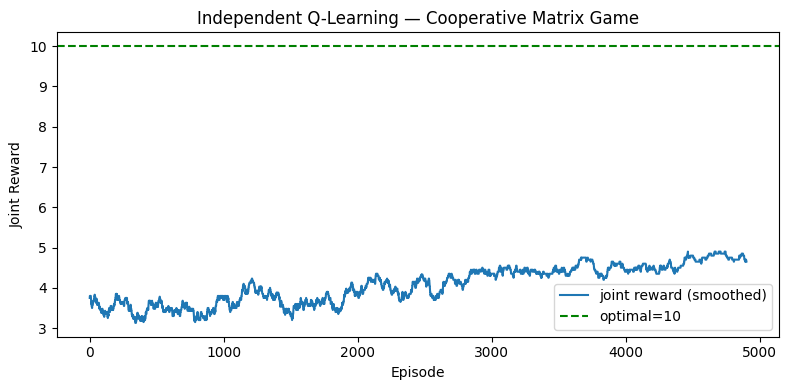

Final Q1: [0.59 4.38 0.  ]  → best action 1
Final Q2: [0.4  4.67 0.  ]  → best action 1
Joint action (1,1) → reward 5.0


In [6]:
# Cooperative matrix game: two agents pick rows/cols of a shared payoff matrix
# Joint reward = payoff[a1, a2]
PAYOFF = np.array([[10, 0, 0],
                   [0,  5, 0],
                   [0,  0, 8]], dtype=float)

n_actions = 3
Q1 = np.zeros(n_actions); Q2 = np.zeros(n_actions)
alpha, eps, n_ep = 0.1, 0.3, 5000
rewards = []

for t in range(n_ep):
    # Decaying exploration
    e = max(0.05, eps*(1 - t/n_ep))
    a1 = np.random.randint(3) if np.random.rand()<e else Q1.argmax()
    a2 = np.random.randint(3) if np.random.rand()<e else Q2.argmax()
    r = PAYOFF[a1, a2]
    Q1[a1] += alpha*(r - Q1[a1])
    Q2[a2] += alpha*(r - Q2[a2])
    rewards.append(r)

smooth = lambda x,w=100: np.convolve(x,np.ones(w)/w,mode="valid")
plt.figure(figsize=(8,4))
plt.plot(smooth(rewards), label="joint reward (smoothed)")
plt.axhline(PAYOFF.max(), color="green", ls="--", label=f"optimal={int(PAYOFF.max())}")
plt.xlabel("Episode"); plt.ylabel("Joint Reward")
plt.title("Independent Q-Learning — Cooperative Matrix Game")
plt.legend(); plt.tight_layout(); plt.show()

print(f"Final Q1: {Q1.round(2)}  → best action {Q1.argmax()}")
print(f"Final Q2: {Q2.round(2)}  → best action {Q2.argmax()}")
print(f"Joint action ({Q1.argmax()},{Q2.argmax()}) → reward {PAYOFF[Q1.argmax(),Q2.argmax()]}")
